# Students' Social Media Habits vs. Productivity
### CS 5100 Final Project
### Authors: Emma Bartnick, Elizabeth Fallat, and Even Laukli

The following dataset was pulled from Kaggle: [Student's Social Media Habits vs. Productivity](https://www.kaggle.com/datasets/racchie/students-social-media-habits-vs-productivity)

Our goal is to preprocess the data, do some exploratory analysis, and try to reproduce some of the results shared in an [existing project posted on Kaggle](https://www.kaggle.com/code/racchie/student-social-media-habits-analyser) using both regression and classification models. 

### Import libraries and read in the dataset
Pandas, numpy, and sklearn libraries are imported in order to process and analysze the dataset.  
We check out the first few rows of the dataset to see what the data looks like in each column.  
We check for missing values in each column. 

In [2]:
# import necessary dependencies 
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

df = pd.read_csv("student_phone_addiction_affects_on_productivity(in).csv")
print(df.head())

# columns:
# age, daily_screen_time, social_media_hours, study_hours, sleep_hours, notifications_per_day, focus_score, 
# coffee_per_day,breaks_per_day, night_usage, distraction_score, addiction_level, productivity_score

# check for missing values and NANs
print(df.isna().sum())
print(df.columns[df.isna().any()])

# check how many values there are for addiction levels to encode it
print(df['addiction_level'].unique())

    age  daily_screen_time  social_media_hours  study_hours  sleep_hours  \
0  21.0               5.95                2.81         2.61     7.377325   
1  34.0               3.82                2.33         0.28     7.612689   
2  29.0               3.57                1.64         5.21     6.143298   
3  25.0              10.27                4.37         4.28     4.012145   
4  22.0               2.42                1.60         3.67     6.953253   

   notifications_per_day  focus_score  coffee_per_day  breaks_per_day  \
0             290.254742          NaN             2.0             1.0   
1             270.571074        93.65             1.0             3.0   
2             134.054219       100.00             0.0             5.0   
3             233.019834        94.71             2.0             2.0   
4              19.381791       100.00             0.0             3.0   

   night_usage  distraction_score addiction_level  productivity_score  
0          0.0              7.85

### Encode addiction level and fill missing values
Because the addiction level data is categorical instead of numerical, it needs to be encoded. 
We cannot fill missing values with a median or mean because that would risk having decimal values. So we replace all missing values with the mode, and then we encode the categories to numerical values (0 = Low addiction level, 1 = medium, 2 = high).  
The remaining columns, which were already numerical values, can be handled differently. Missing values are replaced with the median. The median is preffered over mean because it is not skewed by extreme outliers. 

In [3]:
# Fill missing addiction levels with the mode before encoding it
df['addiction_level'] = df['addiction_level'].fillna(df['addiction_level'].mode()[0])
level_map = {'Low': 0, 'Medium': 1, 'High': 2}
df['addiction_level'] = df['addiction_level'].map(level_map)

# Confirm addicition level is numeric now
print(df['addiction_level'].isna().sum())
print(df['addiction_level'].dtype)

# fill rest of the missing values with median
num_cols = df.select_dtypes(include='number').columns
print(df[num_cols].skew())
df[num_cols] = df[num_cols].fillna(df[num_cols].median())


0
int64
age                     -0.021320
daily_screen_time        0.244566
social_media_hours       0.657158
study_hours             -0.041895
sleep_hours             -0.018741
notifications_per_day    0.866399
focus_score             -2.462148
coffee_per_day           0.295010
breaks_per_day           0.469528
night_usage             -0.334850
distraction_score        0.172341
addiction_level         -0.171728
productivity_score       0.297847
dtype: float64


In [4]:
# final check for missing values and NANs
print(df.isna().sum())
print(df.columns[df.isna().any()])

age                      0
daily_screen_time        0
social_media_hours       0
study_hours              0
sleep_hours              0
notifications_per_day    0
focus_score              0
coffee_per_day           0
breaks_per_day           0
night_usage              0
distraction_score        0
addiction_level          0
productivity_score       0
dtype: int64
Index([], dtype='object')


### Check for any duplicate rows

In [5]:
# check for duplicates
print(df.duplicated().sum())
df = df.drop_duplicates()

# look at the productivity score to see mean/min/max/std
df['productivity_score'].describe()

0


count    10000.000000
mean        37.775427
std         27.137700
min        -14.147106
25%         14.860704
50%         36.179357
75%         57.747677
max        112.152143
Name: productivity_score, dtype: float64

### Check out encoded and filled in data for each column 

In [6]:
# verify columns look good and all the data types are numerical for the models
print(df[num_cols].describe())

df.dtypes

                age  daily_screen_time  social_media_hours   study_hours  \
count  10000.000000       10000.000000        10000.000000  10000.000000   
mean      27.086800           7.076334            4.123600      4.086550   
std        7.074254           2.964752            2.123856      2.271786   
min       15.000000           0.461283            0.000000      0.000000   
25%       21.000000           4.654481            2.479913      2.200073   
50%       27.000000           7.000000            3.771382      4.141210   
75%       33.000000           9.409513            5.430000      5.970000   
max       39.000000          22.372059           11.310630      8.811615   

        sleep_hours  notifications_per_day   focus_score  coffee_per_day  \
count  10000.000000           10000.000000  10000.000000    10000.000000   
mean       6.505929             168.583541     96.253533        1.775098   
std        1.465054              93.679885      7.248072        1.265067   
min        

age                      float64
daily_screen_time        float64
social_media_hours       float64
study_hours              float64
sleep_hours              float64
notifications_per_day    float64
focus_score              float64
coffee_per_day           float64
breaks_per_day           float64
night_usage              float64
distraction_score        float64
addiction_level            int64
productivity_score       float64
dtype: object

In [7]:
# initial correlation between productivity score and all the features 
df.corr()['productivity_score'].sort_values()

social_media_hours      -0.458842
addiction_level         -0.426148
distraction_score       -0.421808
daily_screen_time       -0.356645
night_usage             -0.313989
coffee_per_day          -0.110136
notifications_per_day   -0.075010
age                     -0.000479
sleep_hours              0.192772
breaks_per_day           0.495652
focus_score              0.513559
study_hours              0.686850
productivity_score       1.000000
Name: productivity_score, dtype: float64

### Clip data to remove outliers and invalid values

In [8]:
# Fix physically invalid negative values
# min of -21.352674	notifications per day which isn't possible
# max of 1188.408609 which also seems high and mean is 168
df['notifications_per_day'] = df['notifications_per_day'].clip(lower=0)
df['distraction_score'] = df['distraction_score'].clip(lower=0)

# Cap only the true extreme outliers
cap = df['notifications_per_day'].quantile(0.999)
df['notifications_per_day'] = df['notifications_per_day'].clip(upper=cap)

# output to cleaned csv file
df.to_csv('cleaned_phone_addiction_vs_productivity.csv', index=False)

### Set productivity score as the target column

In [9]:
# split X and y after all cleaning steps
X = df.drop(columns=['productivity_score'])
y = df['productivity_score']

### Split the data into training and testing sets. 
We do this before we scale the data because we do not want the Scaler to learn anything from the test set.  
The data is split to 80% training and 20% testing. 

In [10]:
# Split before scaling to avoid data leakage
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (8000, 12)
X_test: (2000, 12)
y_train: (8000,)
y_test: (2000,)


### Scale the data
The existing data has very different scales for each column, which can lead to bias in a regression algorithm. Therefore, we will use  a StandardScaler to complete z-score standardization of each of the values. 

In [11]:
# Scale features - fit on train only, transform both
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(X_train_scaled[:5])

[[ 1.40291383 -0.03600057 -0.09527556  0.02188797  1.36597916 -0.01825109
   0.51484854 -0.33919106  0.57576828  0.82331789 -0.01778824 -0.23285004]
 [ 0.12941892 -1.42409955 -1.02679011  1.70699423  0.46230784  0.3227068
   0.51484854 -0.61548943  1.08495158 -1.21459768 -1.04461739 -1.74363697]
 [-1.28557542 -1.36312557 -0.79168329  0.02575669  0.8803797  -0.19500481
   0.51484854 -0.61548943 -0.47159328 -1.21459768 -1.12618793 -0.23285004]
 [ 1.40291383 -0.39516481 -0.75788637  1.10654913 -0.32650923 -0.21145822
   0.51484854  0.17322186  0.68114362 -1.21459768 -1.43915245 -0.23285004]
 [ 0.55391722 -1.00027842 -0.08800902  0.55586632 -1.13021649 -1.04948035
   0.13614349  1.25404558  1.40871178 -1.21459768 -0.78277448 -0.23285004]]


In [12]:
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

from sklearn.linear_model import LinearRegression, Ridge, lasso_path
from sklearn.ensemble import RandomForestRegressor
from sklearn.pipeline import Pipeline
from sklearn.model_selection import cross_val_score, learning_curve
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.inspection import permutation_importance, PartialDependenceDisplay

sns.set_theme(style='whitegrid')
feature_names = list(X_train.columns)
print('features:', len(feature_names))

features: 12


Visualizing imputed values at median for the missing entries in the dataset

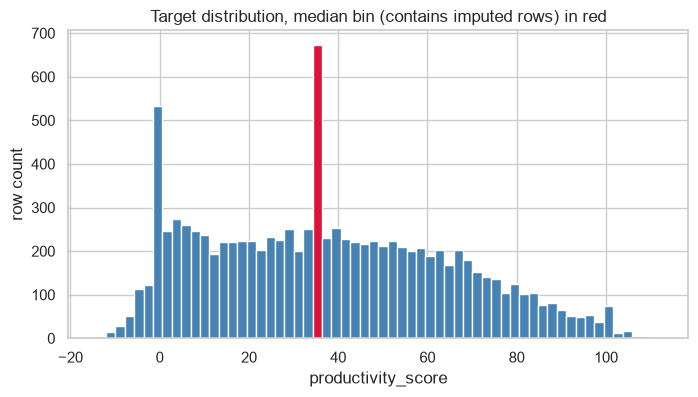

median: 36.179
rows precisely on the median: 464


In [13]:
median_val = df['productivity_score'].median()

fig, ax = plt.subplots(figsize=(8, 4))
counts, bin_edges, patches = ax.hist(df['productivity_score'], bins=60, color='steelblue', edgecolor='white')
for left, right, patch in zip(bin_edges[:-1], bin_edges[1:], patches):
    if left <= median_val < right:
        patch.set_facecolor('crimson')
ax.set_xlabel('productivity_score')
ax.set_ylabel('row count')
ax.set_title('Target distribution, median bin (contains imputed rows) in red')
plt.show()
 
print('median:', round(median_val, 3)) 
print('rows precisely on the median:', int((df['productivity_score'] == median_val).sum()))

Looking at features before and after scaling: 

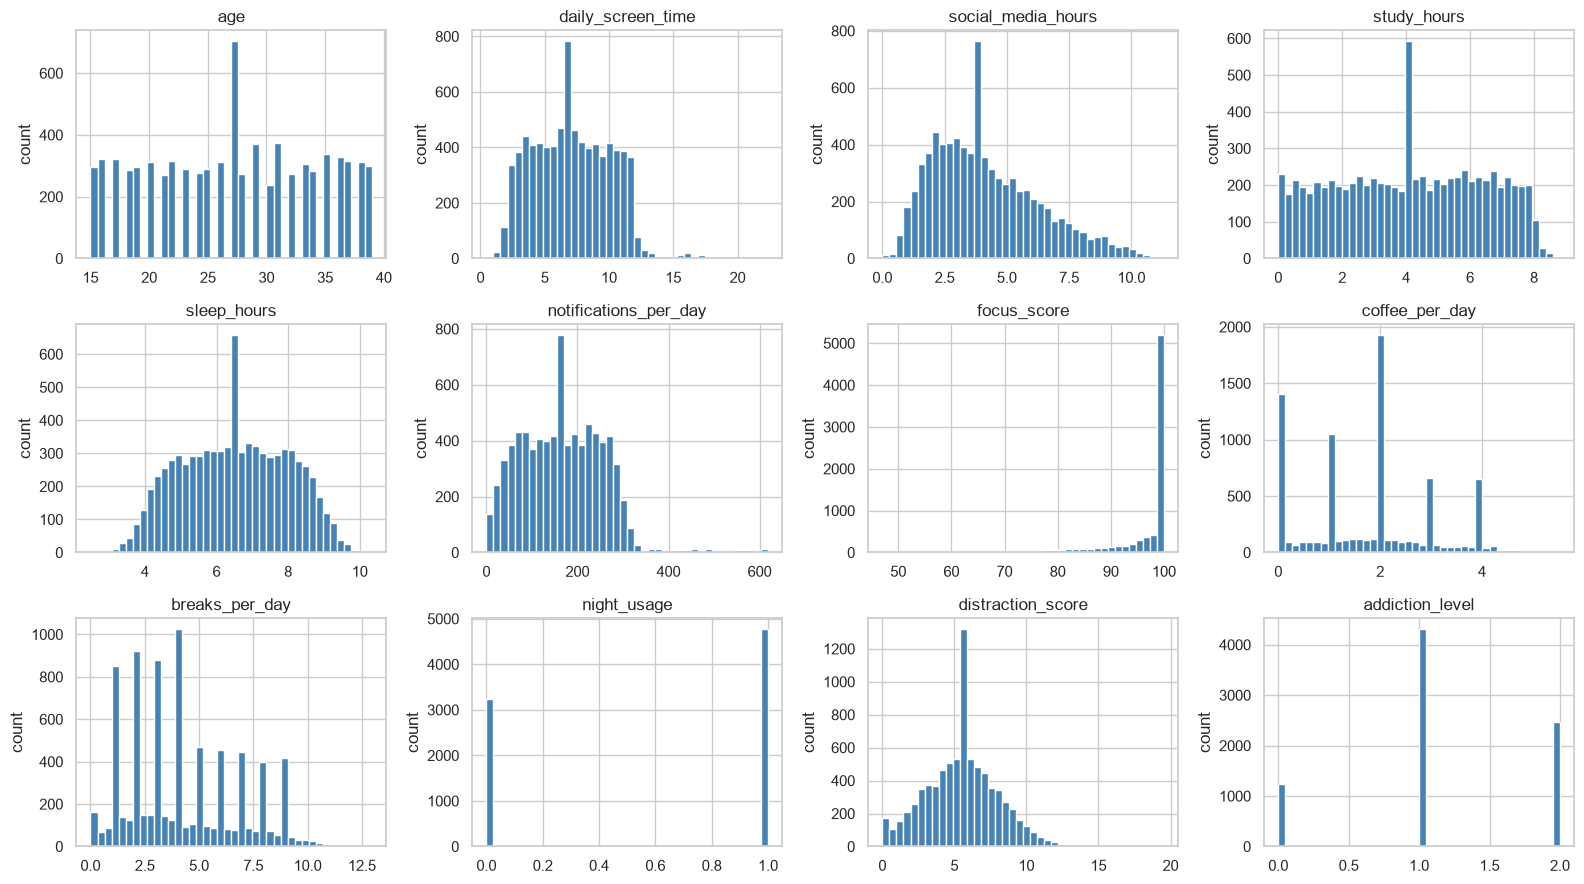

In [14]:
fig, axes = plt.subplots(3, 4, figsize=(16, 9))
for ax, col in zip(axes.ravel(), feature_names):
    ax.hist(X_train[col], bins=40, color='steelblue')
    ax.set_title(col)
    ax.set_ylabel('count')
plt.tight_layout()
plt.show()

After Scaling:

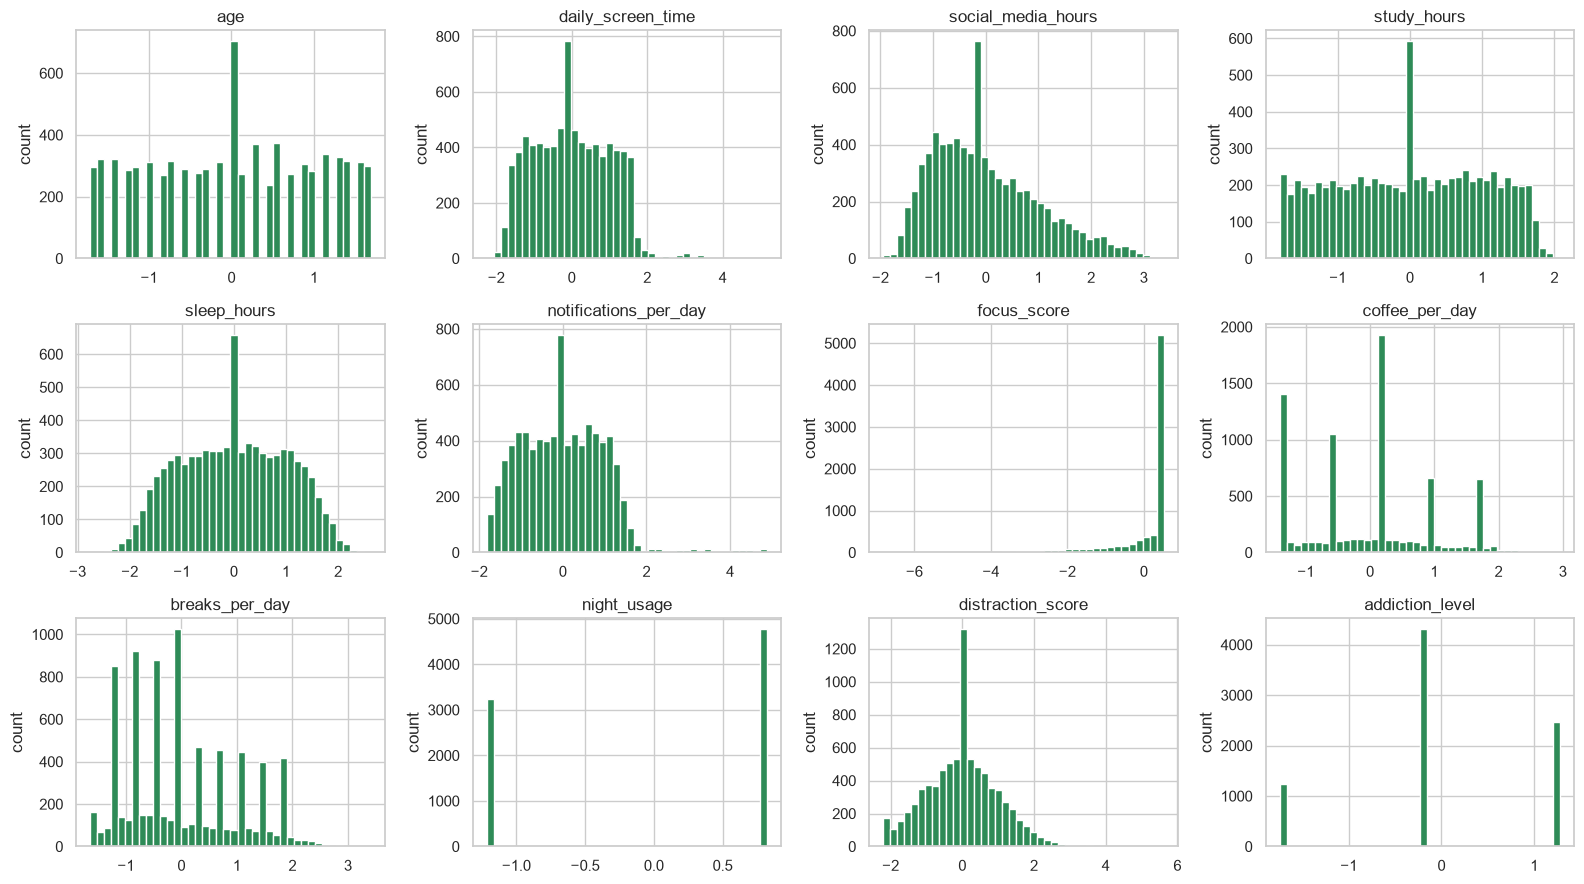

In [15]:
fig, axes = plt.subplots(3, 4, figsize=(16, 9))
for i, (ax, col) in enumerate(zip(axes.ravel(), feature_names)):
    ax.hist(X_train_scaled[:, i], bins=40, color='seagreen')
    ax.set_title(col)
    ax.set_ylabel('count')
plt.tight_layout()
plt.show()

Correlation Heatmap

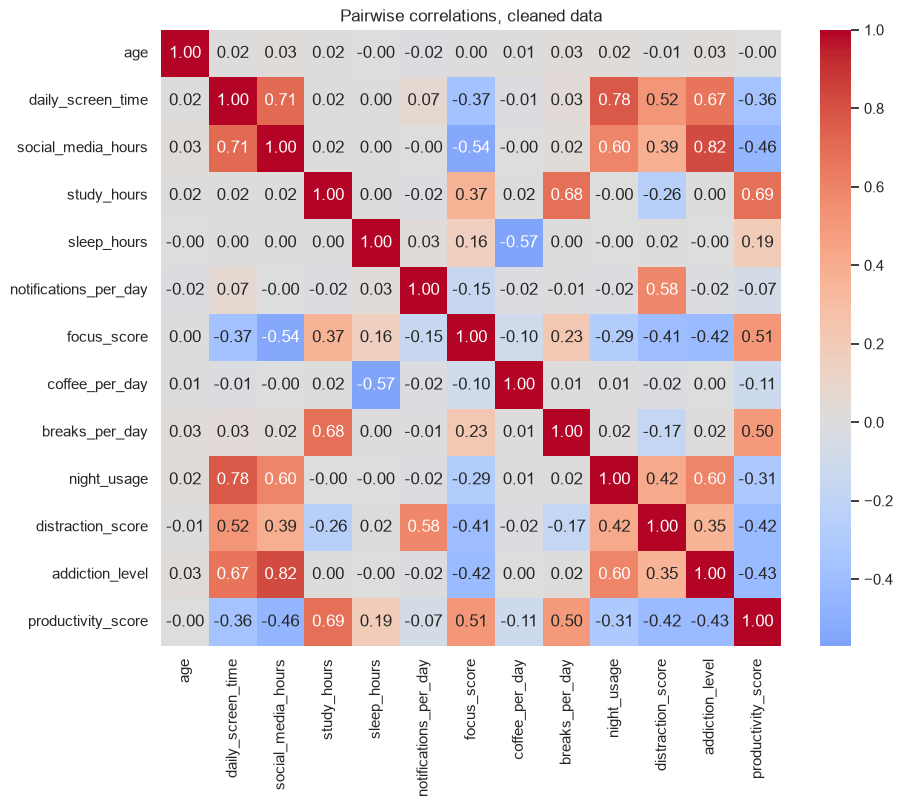

In [16]:
corr = df.corr()

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, ax=ax)
ax.set_title('Pairwise correlations, cleaned data')
plt.show()

Note: 
1. addiction level with daily screen time and social media hours
2. social media hours with daily screen time
3. daily screen time with social media hours
4. study hours and breaks per day

Ordinary Least Squares for a baseline comparison linear regression model

In [17]:
# Evaluation Helper with a results list to compare as we add models
def evaluate(name, pipe, X_train, y_train, X_test, y_test):
    pipe.fit(X_train, y_train)
    pred_train = pipe.predict(X_train)
    pred_test = pipe.predict(X_test)
    cv_rmse = -cross_val_score(pipe, X_train, y_train, cv=5,
                               scoring='neg_root_mean_squared_error')
    return {
        'model': name,
        'train_rmse': np.sqrt(mean_squared_error(y_train, pred_train)),
        'test_rmse': np.sqrt(mean_squared_error(y_test, pred_test)),
        'train_mae': mean_absolute_error(y_train, pred_train),
        'test_mae': mean_absolute_error(y_test, pred_test),
        'train_r2': r2_score(y_train, pred_train),
        'test_r2': r2_score(y_test, pred_test),
        'cv_rmse_mean': cv_rmse.mean(),
        'cv_rmse_std': cv_rmse.std(),
    }

results = []

In [18]:
ols = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LinearRegression()),
])
results.append(evaluate('ols', ols, X_train, y_train, X_test, y_test))
print(results[-1])

{'model': 'ols', 'train_rmse': np.float64(13.695346438948812), 'test_rmse': np.float64(13.781063000173999), 'train_mae': 10.679228028953657, 'test_mae': 10.724691757985298, 'train_r2': 0.745744146896484, 'test_r2': 0.7402094477111819, 'cv_rmse_mean': np.float64(13.720273983469909), 'cv_rmse_std': np.float64(0.22215419622783036)}


Random Forest

In [19]:
rf = Pipeline([
    ('scaler', StandardScaler()),
    ('model', RandomForestRegressor(random_state=42, n_jobs=-1)),
])
results.append(evaluate('random_forest', rf, X_train, y_train, X_test, y_test))
print(results[-1])

{'model': 'random_forest', 'train_rmse': np.float64(4.706696157241854), 'test_rmse': np.float64(12.86802266609107), 'train_mae': 3.5818031062927265, 'test_mae': 9.882111323817732, 'train_r2': 0.9699698680598664, 'test_r2': 0.7734930399723543, 'cv_rmse_mean': np.float64(12.811308053169228), 'cv_rmse_std': np.float64(0.16957344806675276)}


In [20]:
#Comparison (move down as we add more models)
comparison = pd.DataFrame(results).set_index('model').round(3)
comparison


,train_rmse,test_rmse,train_mae,test_mae,train_r2,test_r2,cv_rmse_mean,cv_rmse_std
model,,,,,,,,
ols,13.695,13.781,10.679,10.725,0.746,0.740,13.720,0.222
random_forest,4.707,12.868,3.582,9.882,0.970,0.773,12.811,0.170


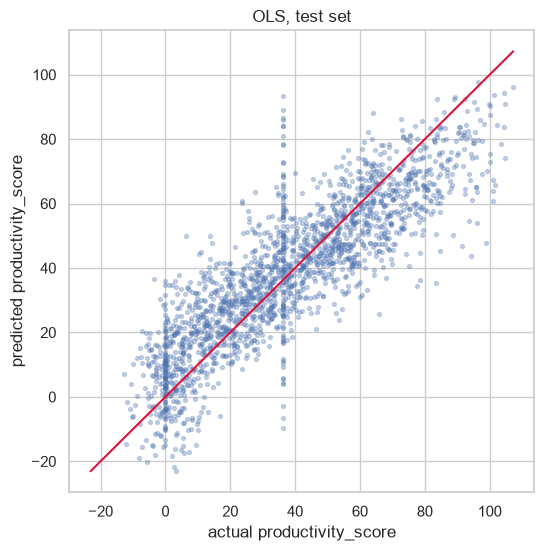

In [21]:
#Predicted vs Actual
pred_test_ols = ols.predict(X_test)

fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(y_test, pred_test_ols, s=8, alpha=0.3)
lims = [min(y_test.min(), pred_test_ols.min()), max(y_test.max(), pred_test_ols.max())]
ax.plot(lims, lims, color='crimson')
ax.set_xlabel('actual productivity_score')
ax.set_ylabel('predicted productivity_score')
ax.set_title('OLS, test set')
plt.show()

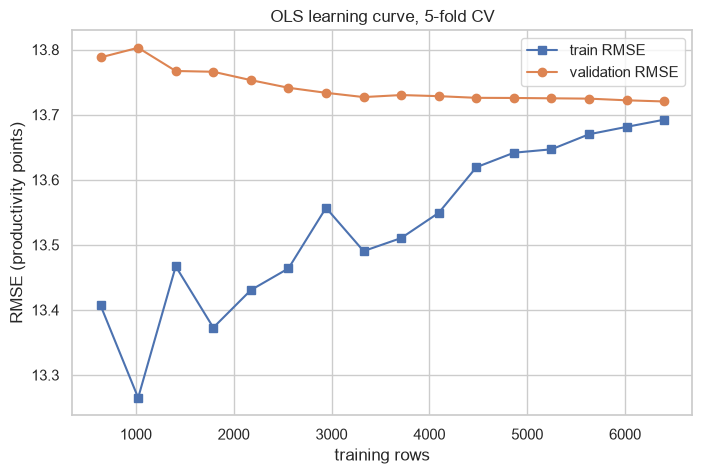

In [22]:
# Learning curve for OLS
train_sizes, train_scores, val_scores = learning_curve(
    ols, X_train, y_train, cv=5,
    train_sizes=np.linspace(0.1, 1, 16),
    scoring='neg_root_mean_squared_error', n_jobs=-1)

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(train_sizes, -train_scores.mean(axis=1), marker='s',label='train RMSE')
ax.plot(train_sizes, -val_scores.mean(axis=1), marker='o', label='validation RMSE')
ax.set_xlabel('training rows')
ax.set_ylabel('RMSE (productivity points)')
ax.set_title('OLS learning curve, 5-fold CV')
ax.legend()
plt.show()

Since the training and validation curves seem to converge past 6000 rows, we can assume that more data would not improve the model performance. The data quality or model form are the limiting factors for the ordinary least squares regression. 

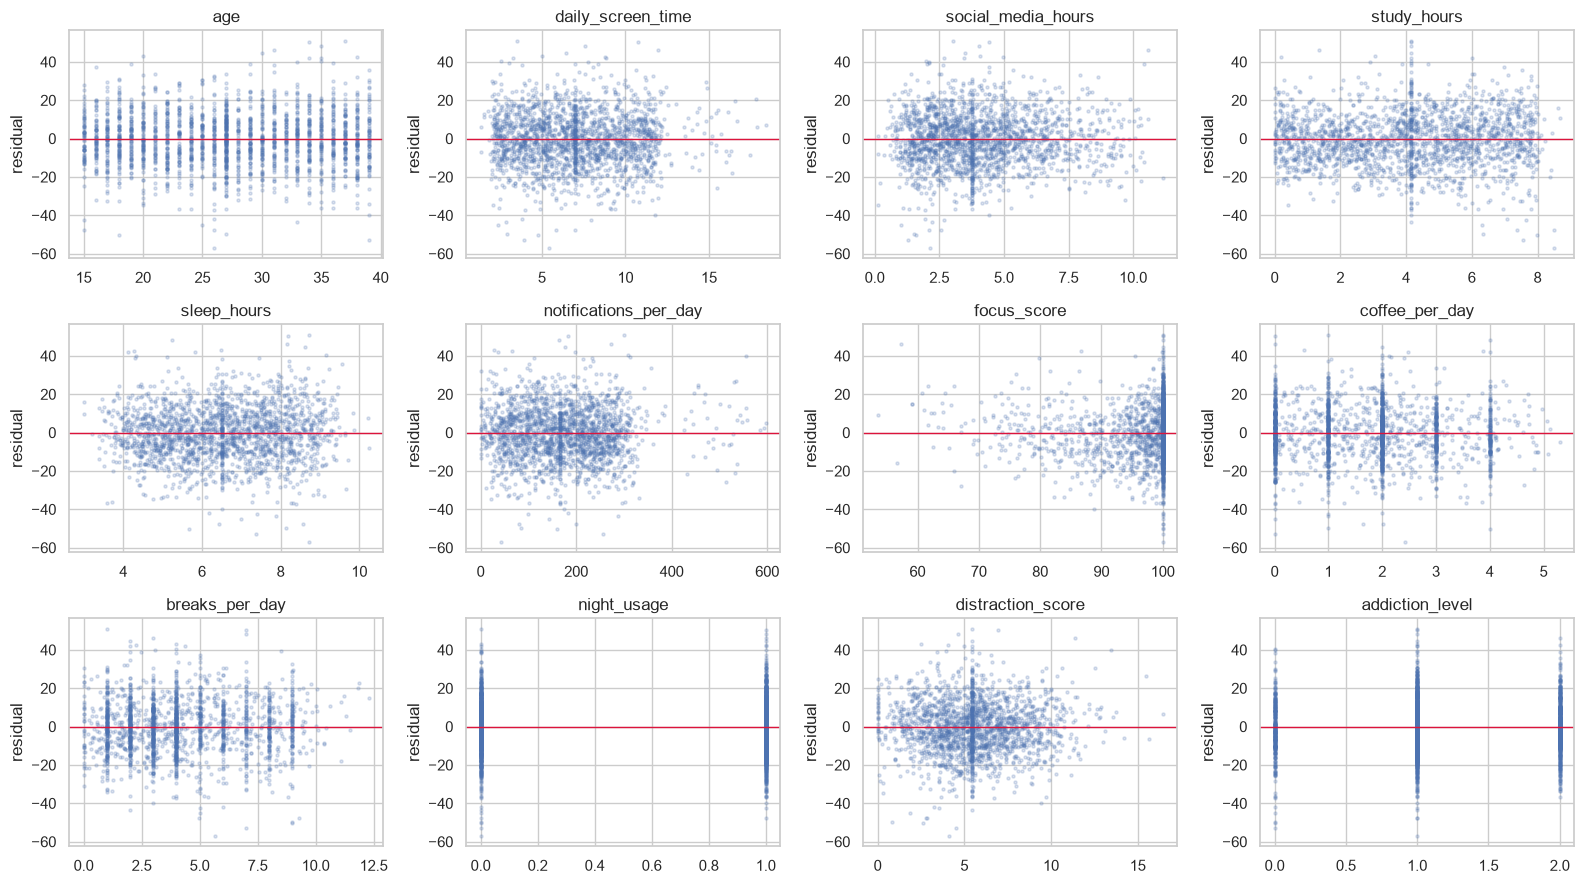

In [ ]:
# Plotting residuals against each feature
residuals = y_test - pred_test_ols
fig, axes = plt.subplots(3, 4, figsize=(16, 9))
for ax, col in zip(axes.ravel(), feature_names):
    ax.scatter(X_test[col], residuals, s=5, alpha=0.2)
    ax.axhline(0, color='crimson', linewidth=1)
    ax.set_title(col)
    ax.set_ylabel('residual')
plt.tight_layout()
plt.show()